# <font color=darkblue>**Universidad Nacional Autónoma de México**
# <font color=darkblue>**Facultad de Ciencias, semestre 2026-2**
# <font color=orange>**Práctica 3 de Análisis Numérico**
# Dra. Úrsula Iturrarán Viveros
## Alumnos:
# Galán Resendiz Andres Roberto
# Valentino Hernández Gael Emiliano

## **Interpolación**

#**Ejercicio 1**

Escribe un programa que encuentre el polinomio interpolante de Newton para un conjunto de puntos $S = \{ (x_i, y_i) : i = 0, 1, 2, \dots, n \}$. Además, el programa debe calcular y devolver el valor de $P(x)$ para cualquier $x$ introducido por el usuario, y graficar $P(x)$ en el intervalo $[x_0, x_n]$.

Considera el siguiente conjunto de datos:

| $x$ | -4 | -3 | -2 | -1 | 0 | 1 | 2 | 3 | 4 |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| $f(x)$ | 0 | 0 | 0 | 0 | 2 | 0 | 0 | 0 | 0 |

Encuentra el polinomio de Newton que interpola los datos de la tabla anterior y grafícalo. Escribe tus conclusiones detallando lo que observas en el comportamiento de la gráfica.

Ingrese x: -3
P(-3.0) = 0.0


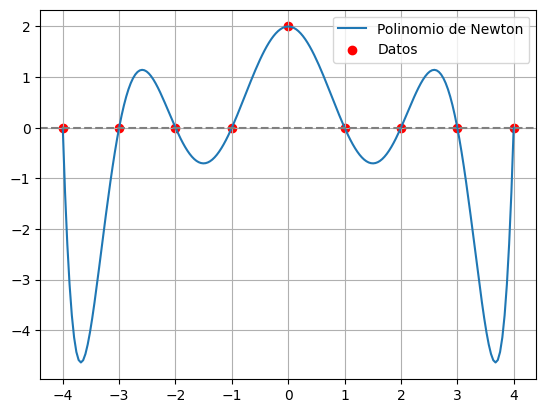

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x_vals = np.array([-4,-3,-2,-1,0,1,2,3,4])
y_vals = np.array([0,0,0,0,2,0,0,0,0])

def newton_coeff(x, y):
    n = len(x)
    coef = np.copy(y).astype(float)
    for j in range(1, n):
        for i in range(n-1, j-1, -1):
            coef[i] = (coef[i] - coef[i-1]) / (x[i] - x[i-j])
    return coef

def newton_eval(coef, x_data, x):
    n = len(coef) - 1
    p = coef[n]
    for k in range(1, n+1):
        p = coef[n-k] + (x - x_data[n-k]) * p
    return p

coef = newton_coeff(x_vals, y_vals)

x_user = float(input("Ingrese x: "))
print(f"P({x_user}) = {newton_eval(coef, x_vals, x_user)}")
# Gráfica
x_fine = np.linspace(-4, 4, 200)
y_fine = [newton_eval(coef, x_vals, xi) for xi in x_fine]

plt.plot(x_fine, y_fine, label="Polinomio de Newton")
plt.scatter(x_vals, y_vals, color='red', label="Datos")
plt.axhline(0, color='gray', linestyle='--')
plt.grid()
plt.legend()
plt.show()

# **Ejercicio 2**

Escribe un programa que encuentre el polinomio interpolante de Lagrange para un conjunto de puntos $S = \{ (x_i, y_i) : i = 0, 1, \dots, n \}$. Además, el programa debe calcular y devolver el valor de $P(x)$ para cualquier $x$ introducido por el usuario, y graficar $P(x)$ en el intervalo $[x_0, x_n]$.

La presión de vapor del agua (en unidades de bar) como función de la temperatura $T$ (en $^\circ\text{C}$) es:

| $T$ | 0 | 10 | 20 | 30 | 40 | 60 | 80 | 100 |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| $P$ | 0.0061 | 0.0123 | 0.0234 | 0.0424 | 0.0738 | 0.1992 | 0.4736 | 1.0133 |

Calcula, mediante el programa anterior, el polinomio que interpola los datos. Por medio del polinomio encontrado, estima los valores de $P(5)$, $P(45)$ y $P(95)$.

Compara tus resultados con los valores conocidos de la presión: $P(5) = 0.008721$, $P(45) = 0.095848$ y $P(95) = 0.84528$. Calcula el error absoluto de los valores obtenidos a través del polinomio interpolante. ¿El polinomio interpolante describe bien la presión de vapor como función de la temperatura?

Introduce un valor de temperatura (T) para evaluar P(x): 5
Para T = 5.0°C, la presión estimada es P = 0.008691 bar

T (°C)     | Estimado     | Real         | Error Absoluto 
-------------------------------------------------------
5          | 0.008691     | 0.008721     | 0.000030       
45         | 0.095919     | 0.095848     | 0.000071       
95         | 0.846173     | 0.845280     | 0.000893       


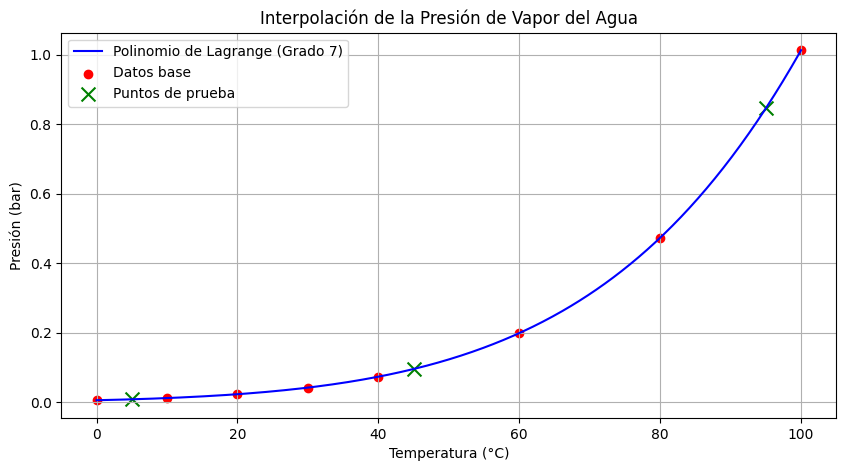

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

T_data = np.array([0, 10, 20, 30, 40, 60, 80, 100])
P_data = np.array([0.0061, 0.0123, 0.0234, 0.0424, 0.0738, 0.1992, 0.4736, 1.0133])

def lagrange_interp(x, x_data, y_data):
    n = len(x_data)
    total = 0.0
    for i in range(n):
        li = 1.0
        for j in range(n):
            if j != i:
                li *= (x - x_data[j]) / (x_data[i] - x_data[j])
        total += y_data[i] * li
    return total
try:
    x_user = float(input("Introduce un valor de temperatura (T) para evaluar P(x): "))
    p_user = lagrange_interp(x_user, T_data, P_data)
    print(f"Para T = {x_user}°C, la presión estimada es P = {p_user:.6f} bar\n")
except ValueError:
    print("Entrada no válida\n")
puntos_test = [5, 45, 95]
reales = [0.008721, 0.095848, 0.84528]
print(f"{'T (°C)':<10} | {'Estimado':<12} | {'Real':<12} | {'Error Absoluto':<15}")
print("-" * 55)
for t, r in zip(puntos_test, reales):
    est = lagrange_interp(t, T_data, P_data)
    err = abs(est - r)
    print(f"{t:<10} | {est:<12.6f} | {r:<12.6f} | {err:<15.6f}")
T_plot = np.linspace(min(T_data), max(T_data), 500)
P_plot = [lagrange_interp(t, T_data, P_data) for t in T_plot]
plt.figure(figsize=(10, 5))
plt.plot(T_plot, P_plot, 'b-', label='Polinomio de Lagrange (Grado 7)')
plt.scatter(T_data, P_data, color='red', label='Datos base')
plt.scatter(puntos_test, [lagrange_interp(t, T_data, P_data) for t in puntos_test],
            color='green', marker='x', s=100, label='Puntos de prueba')
plt.title('Interpolación de la Presión de Vapor del Agua')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Presión (bar)')
plt.legend()
plt.grid(True)
plt.show()

#**Ejercicio 3**

Escribe un programa que calcule un spline cuadrático $Q(x)$ que interpole un conjunto de datos $S = \{ (x_i, y_i) : i = 0, 1, \dots, n \}$. Además, el programa debe calcular y devolver el valor de $Q(x)$ para cualquier $x$ introducido por el usuario, y graficar $Q(x)$ en el intervalo $[x_0, x_n]$.

Considera los siguientes valores de una función:

| $x$ | -1 | 0 | 1 | 2 |
| :---: | :---: | :---: | :---: | :---: |
| $f(x)$ | -4 | -1 | 2 | 23 |

Calcula, mediante el programa anterior, el spline cuadrático $Q(x)$ que interpola los datos y estima el valor de $Q(1.5)$.

Q(1.5) = 7.25


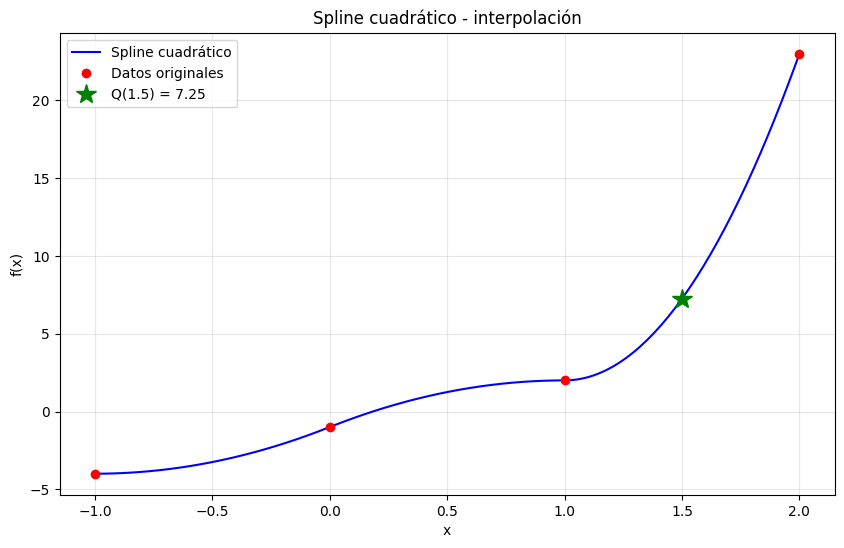

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x_vals = np.array([-1, 0, 1, 2])
y_vals = np.array([-4, -1, 2, 23])

a = [3, -3, 21]
b = [0, 6, 0]

def spline_cuadratico(x):
    for i in range(len(x_vals)-1):
        if x_vals[i] <= x <= x_vals[i+1]:
            dx = x - x_vals[i]
            return a[i]*dx*dx + b[i]*dx + y_vals[i]
    if x < x_vals[0]:
        dx = x - x_vals[0]
        return a[0]*dx*dx + b[0]*dx + y_vals[0]
    else:
        i = len(x_vals)-2
        dx = x - x_vals[i]
        return a[i]*dx*dx + b[i]*dx + y_vals[i]
x_usuario = 1.5
resultado = spline_cuadratico(x_usuario)
print(f"Q({x_usuario}) = {resultado}")
x_fino = np.linspace(-1, 2, 200)
y_fino = [spline_cuadratico(x) for x in x_fino]
plt.figure(figsize=(10, 6))
plt.plot(x_fino, y_fino, 'b-', label='Spline cuadrático')
plt.plot(x_vals, y_vals, 'ro', label='Datos originales')
plt.plot(x_usuario, resultado, 'g*', markersize=15, label=f'Q({x_usuario}) = {resultado}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Spline cuadrático - interpolación')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()
while True:
    try:
        entrada = input("\n¿Quieres evaluar en otro x? (Enter para salir): ")
        if not entrada:
            break
        x_eval = float(entrada)
        print(f"Q({x_eval}) = {spline_cuadratico(x_eval)}")
    except:
        break

#**Ejercicio 4**

En un experimento se produjeron los siguientes datos:

| $t$ | 0.0 | 0.5 | 1.0 | 6.0 | 7.0 | 9.0 |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| $y$ | 0.0 | 1.6 | 2.0 | 2.0 | 1.5 | 0.0 |

Se desea interpolar los datos con una curva suave con la esperanza de obtener valores razonables de $y$ para valores de $t$ entre los puntos en los que se hicieron las medidas.

a) Escribe un programa que utilice el método de tu preferencia para determinar el polinomio de grado cinco que interpole los datos y que lo grafique en el rango $0 \leq t \leq 9$.

b) Escribe un programa que determine un spline cúbico natural que interpole los datos dados y que lo grafique en el intervalo $0 \leq t \leq 9$.

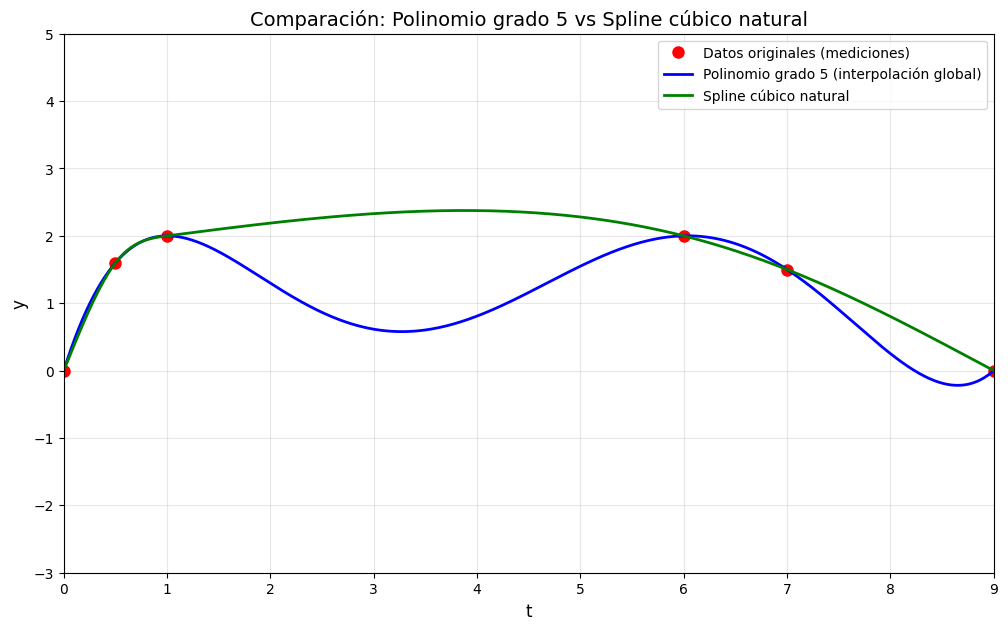

Resultados para valores intermedios:
--------------------------------------------------
t = 2.0:
  Polinomio grado 5: 1.2963
  Spline cúbico:     2.1897

t = 3.0:
  Polinomio grado 5: 0.6143
  Spline cúbico:     2.3297

t = 4.0:
  Polinomio grado 5: 0.8095
  Spline cúbico:     2.3750

t = 5.0:
  Polinomio grado 5: 1.5503
  Spline cúbico:     2.2801

t = 8.0:
  Polinomio grado 5: 0.2519
  Spline cúbico:     0.8029



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

t = np.array([0.0, 0.5, 1.0, 6.0, 7.0, 9.0])
y = np.array([0.0, 1.6, 2.0, 2.0, 1.5, 0.0])
n = len(t)
V = np.vander(t, N=n, increasing=True)
coefs = np.linalg.solve(V, y)

def poly_eval(t_eval, coefs):
    return sum(c * (t_eval ** i) for i, c in enumerate(coefs))
spline_natural = CubicSpline(t, y, bc_type='natural')
t_fino = np.linspace(0, 9, 500)
y_poly = [poly_eval(ti, coefs) for ti in t_fino]
y_spline = spline_natural(t_fino)
plt.figure(figsize=(12, 7))
plt.plot(t, y, 'ro', markersize=8, label='Datos originales (mediciones)')
plt.plot(t_fino, y_poly, 'b-', linewidth=2, label='Polinomio grado 5 (interpolación global)')
plt.plot(t_fino, y_spline, 'g-', linewidth=2, label='Spline cúbico natural')
plt.xlabel('t', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Comparación: Polinomio grado 5 vs Spline cúbico natural', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim(0, 9)
plt.ylim(-3, 5)
plt.show()

print("Resultados para valores intermedios:")
print("-" * 50)
t_prueba = [2.0, 3.0, 4.0, 5.0, 8.0]
for ti in t_prueba:
    y_p = poly_eval(ti, coefs)
    y_s = spline_natural(ti)
    print(f"t = {ti:.1f}:")
    print(f"  Polinomio grado 5: {y_p:.4f}")
    print(f"  Spline cúbico:     {y_s:.4f}")
    print()

# **Integración numérica**

#**Ejercicio 5**

La gráfica de la función $f(x) = \sqrt{1-x^2}$, en el intervalo $[-1,1]$, corresponde a la mitad superior de una circunferencia unitaria con centro en el origen. Entonces, se cumple la siguiente relación:

$$\pi = 2\int_{-1}^{1}\sqrt{1-x^2} \, dx$$

Luego, es posible aproximar $\pi$ mediante la suma:

$$\pi \approx 2 \sum_{k=0}^{n-1} \sqrt{1-(x_{k+1})^2} \cdot (x_{k+1}-x_k)$$

donde $n \geq 2$, $x_k = x_0 + k(2/n)$ para $k = 0, 1, 2, \dots, n$, $x_0 = -1$ y $x_n = 1$. En teoría, la aproximación mejora para valores de $n$ grandes. Escribe un programa que, al introducir un valor de $n$, aproxime el valor de $\pi$ mediante esta relación.

Escribe otro programa que calcule la aproximación de $\pi$ mediante la regla de Simpson 1/3 compuesta, considerando $n$ subintervalos (con $n$ par), la función $f(x) = 2\sqrt{1-x^2}$ y el intervalo $[-1,1]$.

Compara ambos métodos generando una tabla de aproximaciones de $\pi$ para $n = 4, 10, 50, 100$. Finalmente, responde:

* ¿Qué método es mejor para aproximar $\pi$?
* ¿A qué crees que se deba este comportamiento?

In [ ]:
import numpy as np
import pandas as pd
def f(x):
    return np.sqrt(1 - x**2)
def g(x):
    return 2 * np.sqrt(1 - x**2)
def metodo_rectangulos_derecha(n):
    h = 2 / n
    x = np.linspace(-1, 1, n+1)
    suma = 0.0
    for k in range(n):
        suma += f(x[k+1]) * h
    return 2 * suma
def metodo_simpson(n):
    if n % 2 != 0:
        raise ValueError("n debe ser par para Simpson compuesto")
    h = 2 / n
    x = np.linspace(-1, 1, n+1)
    suma = g(x[0]) + g(x[n])
    for k in range(1, n, 2):
        suma += 4 * g(x[k])
    for k in range(2, n-1, 2):
        suma += 2 * g(x[k])
    return (h/3) * suma
valores_n = [4, 10, 50, 100]
resultados = []

pi_real = np.pi
print("Comparación de métodos para aproximar π")
print(f"Valor real de π: {pi_real:.10f}\n")
print(f"{'n':<6} {'Rectángulos (derecha)':<25} {'Error rectángulos':<20} {'Simpson 1/3':<20} {'Error Simpson':<20}")


for n in valores_n:
    aprox_rect = metodo_rectangulos_derecha(n)
    error_rect = abs(aprox_rect - pi_real)

    aprox_simpson = metodo_simpson(n)
    error_simpson = abs(aprox_simpson - pi_real)
    print(f"{n:<6} {aprox_rect:<25.10f} {error_rect:<20.10e} {aprox_simpson:<20.10f} {error_simpson:<20.10e}")
    resultados.append({
        'n': n,
        'rectangulos': aprox_rect,
        'error_rect': error_rect,
        'simpson': aprox_simpson,
        'error_simpson': error_simpson
    })
print("Análisis de convergencia:")
# Para n=50 y n=100
if len(valores_n) >= 2:
    n1, n2 = valores_n[-2], valores_n[-1]
    err1_rect = resultados[-2]['error_rect']
    err2_rect = resultados[-1]['error_rect']
    err1_simp = resultados[-2]['error_simpson']
    err2_simp = resultados[-1]['error_simpson']

    ratio_rect = err1_rect / err2_rect
    ratio_simp = err1_simp / err2_simp

    print(f"Para rectángulos: h se reduce a la mitad, error se reduce factor ≈ {ratio_rect:.2f} (teórico O(h): factor 2)")
    print(f"Para Simpson:     h se reduce a la mitad, error se reduce factor ≈ {ratio_simp:.2f} (teórico O(h^4): factor 16)")
    print("\nNota: La singularidad en los extremos reduce el orden real de Simpson.")

Comparación de métodos para aproximar π
Valor real de π: 3.1415926536

n      Rectángulos (derecha)     Error rectángulos    Simpson 1/3          Error Simpson       
4      2.7320508076              4.0954184602e-01     2.9760677434         1.6552491016e-01    
10     3.0370488289              1.0454382471e-01     3.1001739601         4.1418693539e-02    
50     3.1321963109              9.3963426868e-03     3.1379123350         3.6803186001e-03    
100    3.1382685111              3.3241424913e-03     3.1402925778         1.3000757595e-03    
Análisis de convergencia:
Para rectángulos: h se reduce a la mitad, error se reduce factor ≈ 2.83 (teórico O(h): factor 2)
Para Simpson:     h se reduce a la mitad, error se reduce factor ≈ 2.83 (teórico O(h^4): factor 16)

Nota: La singularidad en los extremos reduce el orden real de Simpson.


# **Ejercicio 6**

La función logaritmo natural se define como:

$$\log(x) = \int_{1}^{x} \frac{1}{t} \, dt$$

Escribe un programa que, mediante una regla de integración numérica compuesta de tu elección (punto medio, trapecio o Simpson) y considerando $n = 10^5$ subintervalos, calcule el valor aproximado de $\log(x)$ para cualquier número $x > 0$ introducido por el usuario.

*Sugerencia: Divide el problema en tres casos para su implementación algorítmica: $x < 1$, $x = 1$ y $x > 1$.*

Crea una rutina que utilice tu programa anterior para generar una tabla mostrando el valor de $\log(x_j)$ para $x_j = 10^{-4+j}$, con $j = 0, 1, 2, \dots, 20$. En la misma tabla, debes incluir el valor de $\log(x_j)$ calculado por la función predeterminada de tu lenguaje de programación y el error absoluto entre tu aproximación y el valor predeterminado.

A partir de los resultados obtenidos en tu tabla, responde:
* ¿Qué sucede con la aproximación para valores pequeños de $x$?
* ¿Qué sucede con la aproximación para valores grandes de $x$?
* Explica detalladamente a qué crees que se deban estos comportamientos.

In [ ]:
import numpy as np
import pandas as pd

def simpson_log(x, n=10**5):
    if x <= 0:
        return np.nan
    if x == 1:
        return 0.0
    a, b = (x, 1.0) if x < 1 else (1.0, x)
    if n % 2 != 0: n += 1
    h = (b - a) / n
    t = np.linspace(a, b, n + 1)
    f_t = 1 / t
    suma = f_t[0] + f_t[-1]
    suma += 4 * np.sum(f_t[1:-1:2])
    suma += 2 * np.sum(f_t[2:-2:2])
    resultado = (h / 3) * suma
    return -resultado if x < 1 else resultado
resultados = []
for j in range(21):
    xj = 10**(-4 + j)
    aprox = simpson_log(xj)
    real = np.log(xj)
    error = abs(aprox - real)

    resultados.append({
        'j': j,
        'x_j': xj,
        'Log Aproximado': aprox,
        'Log Real (np.log)': real,
        'Error Absoluto': error
    })
df = pd.DataFrame(resultados)
pd.options.display.float_format = '{:.10e}'.format

print("Tabla de comparación para log(x)")
print("="*100)
print(df.to_string(index=False))
print("Preguntas")
print("1. ¿Qué sucede con la aproximación para valores pequeños de x?")
print("   Para x muy pequeños (ej. 10^-4), el intervalo de integración [x, 1] es grande.")
print("   Pero el error suele ser bajo porque la función 1/t es suave en ese rango.")

print("\n2. ¿Qué sucede con la aproximación para valores grandes de x?")
print("   Para x muy grandes el intervalo [1, x] se vuelve masivo.")
print("   A pesar de usar n=10^5 subintervalos, el ancho de cada subintervalo (h) crece")
print("   mucho, lo que provoca que el error absoluto aumente considerablemente.")

print("\n3. Explicación detallada:")
print("   La precisión de Simpson depende de h = (b-a)/npor lo que si i (b-a) es gigantesco,")
print("   h deja de ser 'pequeño' y la parábola de Simpson ya no ajusta bien la curva 1/t.")

Tabla de comparación para log(x)
 j              x_j    Log Aproximado  Log Real (np.log)   Error Absoluto
 0 1.0000000000e-04 -9.2103436279e+00  -9.2103403720e+00 3.2559475702e-06
 1 1.0000000000e-03 -6.9077552793e+00  -6.9077552790e+00 3.3192293358e-10
 2 1.0000000000e-02 -4.6051701860e+00  -4.6051701860e+00 3.1974423109e-14
 3 1.0000000000e-01 -2.3025850930e+00  -2.3025850930e+00 4.4408920985e-16
 4 1.0000000000e+00  0.0000000000e+00   0.0000000000e+00 0.0000000000e+00
 5 1.0000000000e+01  2.3025850930e+00   2.3025850930e+00 0.0000000000e+00
 6 1.0000000000e+02  4.6051701860e+00   4.6051701860e+00 3.1086244690e-14
 7 1.0000000000e+03  6.9077552793e+00   6.9077552790e+00 3.3192382176e-10
 8 1.0000000000e+04  9.2103436279e+00   9.2103403720e+00 3.2559475667e-06
 9 1.0000000000e+05  1.1525758362e+01   1.1512925465e+01 1.2832896934e-02
10 1.0000000000e+06  1.5476363616e+01   1.3815510558e+01 1.6608530584e+00
11 1.0000000000e+07  4.5635478263e+01   1.6118095651e+01 2.9517382612e+01
12 1.

#**Ejercicio 7**

El periodo de un péndulo simple está determinado por una integral elíptica completa de primer tipo:

$$K(x) = \int_{0}^{\pi/2} \frac{1}{\sqrt{1 - x^2 \sin^2(\theta)}} \, d\theta$$

Escribe un programa que, mediante una regla de integración numérica compuesta de tu elección (punto medio, trapecio o Simpson) y considerando 1000 subintervalos, calcule y devuelva el valor de $K(x)$ para cualquier valor introducido de $x \in [0, 1)$. Asegúrate de utilizar precisión doble para tus cálculos.

En tu programa, implementa una rutina que grafique $K(x)$ utilizando un número suficiente de valores de $x$ dentro del intervalo $[0, 1)$.

A partir de tus resultados y de la gráfica, responde:
* ¿Cómo es el comportamiento de la función $K(x)$ a medida que $x$ se acerca a $1$?

Ingrese el valor de x (entre 0 y 1, ej. 0.5): 0.4

El valor de K(0.4) con 1000 subintervalos es: 1.639999865865


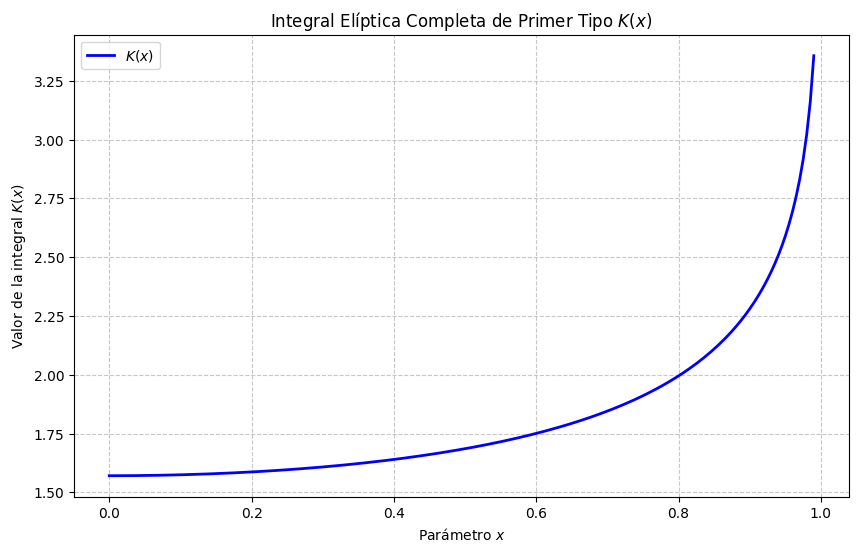

¿Cómo es el comportamiento de la función K(x) a medida que x se acerca a 1?

1. Crecimiento Asintótico: La función crece de forma acelerada y tiende al infinito.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
def integrando(theta, x):
    return 1.0 / np.sqrt(1 - (x**2) * (np.sin(theta)**2))
def simpson_compuesta_K(x, n=1000):
    if n % 2 != 0:
        n += 1
    a = 0
    b = np.pi / 2

    h = (b - a) / n
    theta = np.linspace(a, b, n + 1)
    f_vals = integrando(theta, x)
    suma = f_vals[0] + f_vals[-1]
    suma += 4 * np.sum(f_vals[1:-1:2])
    suma += 2 * np.sum(f_vals[2:-2:2])

    return (h / 3.0) * suma
def graficar_K():
    x_vals = np.linspace(0, 0.99, 200)
    k_vals = [simpson_compuesta_K(x) for x in x_vals]

    plt.figure(figsize=(10, 6))
    plt.plot(x_vals, k_vals, label='$K(x)$', color='blue', linewidth=2)
    plt.title('Integral Elíptica Completa de Primer Tipo $K(x)$')
    plt.xlabel('Parámetro $x$')
    plt.ylabel('Valor de la integral $K(x)$')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.show()
try:
    user_x = float(input("Ingrese el valor de x (entre 0 y 1, ej. 0.5): "))
    if 0 <= user_x < 1:
        resultado = simpson_compuesta_K(user_x)
        print(f"\nEl valor de K({user_x}) con 1000 subintervalos es: {resultado:.12f}")
    else:
        print("Error: x debe estar en el intervalo [0, 1)")
except ValueError:
    print("Entrada no válida.")
graficar_K()
print("¿Cómo es el comportamiento de la función K(x) a medida que x se acerca a 1?")
print("\n1. Crecimiento Asintótico: La función crece de forma acelerada y tiende al infinito.")

#**Ejercicio 8**

Considera la siguiente integral:

$$\int_{-\pi}^{\pi} \frac{250x^2}{\cosh^2[500(x - t)]} \, dx$$

para los valores de $t = 0.5$ y $t = 1.0$.

Escribe un programa que, utilizando el método de cuadratura de Gauss (integración gaussiana) con 2, 3 y 4 nodos, calcule una aproximación de esta integral.

El programa debe generar y mostrar una tabla clara que resuma y compare los resultados obtenidos para cada combinación del valor de $t$ y la cantidad de nodos utilizada.

In [ ]:
import numpy as np
from pandas import DataFrame

def f_stable(x, t):
    """Función numéricamente estable para evitar el overflow de cosh."""
    u = 500 * (x - t)
    mask = np.abs(u) < 700
    res = np.zeros_like(x)
    res[mask] = (250 * x[mask]**2) / (np.cosh(u[mask])**2)
    return res

def gauss_quadrature(t_val, n_nodes):
    a, b = -np.pi, np.pi
    nodes, weights = np.polynomial.legendre.leggauss(n_nodes)
    x_mapped = 0.5 * (b - a) * nodes + 0.5 * (a + b)
    factor = 0.5 * (b - a)
    integral = factor * np.sum(weights * f_stable(x_mapped, t_val))
    return integral
valores_t = [0.5, 1.0]
nodos_lista = [2, 3, 4]

resultados = []
for t in valores_t:
    fila = {"Valor de t": t}
    for n in nodos_lista:
        fila[f"{n} Nodos"] = gauss_quadrature(t, n)
    resultados.append(fila)

df = DataFrame(resultados)
print(df.to_string(index=False))

      Valor de t          2 Nodos          3 Nodos           4 Nodos
5.0000000000e-01 0.0000000000e+00 0.0000000000e+00 4.5065856073e-244
1.0000000000e+00 0.0000000000e+00 0.0000000000e+00  6.3254084876e-27


/tmp/ipykernel_5857/354885060.py:12: RuntimeWarning: overflow encountered in square
  res[mask] = (250 * x[mask]**2) / (np.cosh(u[mask])**2)
